In [90]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score
from sklearn.ensemble import RandomForestClassifier

In [91]:
import pandas as pd
import numpy as np

In [92]:
df = pd.read_csv('wellness_data_clustered.csv')

In [93]:
df.columns

Index(['Age', 'Gender', 'Exercise Level', 'Diet Type', 'Sleep Hours',
       'Stress Level', 'Mental Health Condition', 'Work Hours per Week',
       'Screen Time per Day (Hours)', 'Social Interaction Score',
       'Happiness Score', 'cluster', 'ProgramLabel'],
      dtype='object')

In [94]:
df = df.drop('ProgramLabel',axis=1)

In [95]:
X = df.drop('cluster',axis=1)
y = df['cluster']

In [96]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [97]:
rf_hyperparams = {
    "n_estimators": 300,
    "max_depth": 12,
    "min_samples_split": 5,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "bootstrap": True,
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
}

rf_model = RandomForestClassifier(**rf_hyperparams)
rf_model.fit(X_train,y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,12
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [98]:
y_pred = rf_model.predict(X_test)

In [99]:
from sklearn.metrics import confusion_matrix,f1_score,precision_score,recall_score

In [100]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86       120
           1       0.89      0.85      0.87       125
           2       0.86      0.96      0.91       115
           3       0.88      0.82      0.85       122
           4       0.88      0.92      0.90       118

    accuracy                           0.88       600
   macro avg       0.88      0.88      0.88       600
weighted avg       0.88      0.88      0.88       600



In [101]:
print(confusion_matrix(y_test,y_pred))

[[102   7   3   4   4]
 [  9 106   7   0   3]
 [  0   0 110   4   1]
 [  4   4   7 100   7]
 [  2   2   1   5 108]]


In [102]:
print(accuracy_score(y_test,y_pred))

0.8766666666666667


In [103]:
print(precision_score(y_test,y_pred,average='weighted'))

0.8772706754966386


In [104]:
print(f1_score(y_test,y_pred,average='weighted'))

0.8760034104810527


In [105]:
print(recall_score(y_test,y_pred,average='weighted'))

0.8766666666666667


In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

Saved plot: rf_auc_vs_training_size.png
Saved plot: rf_auc_vs_training_size.pdf


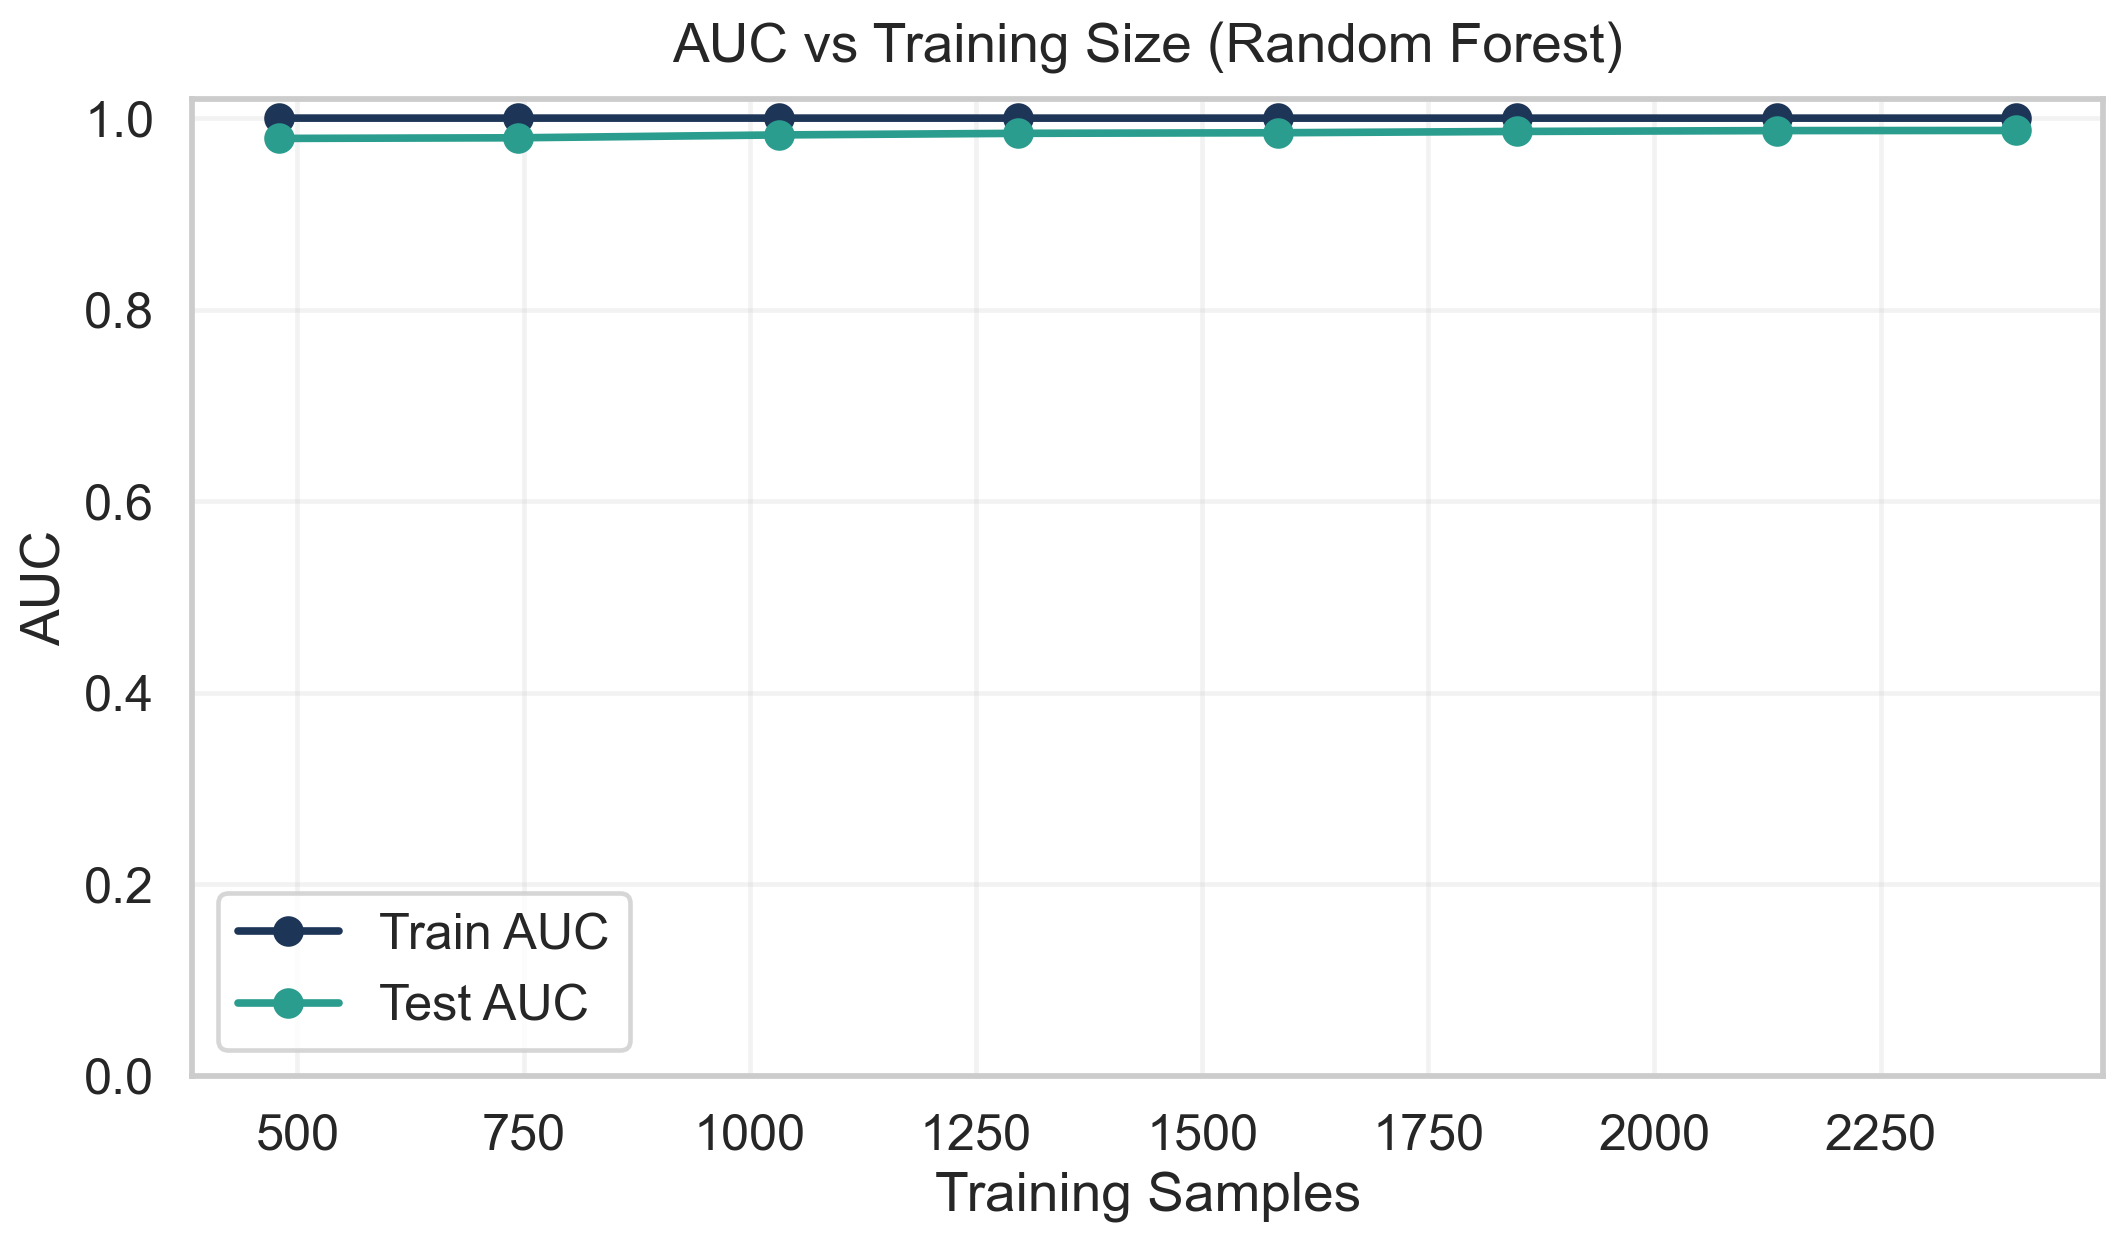

In [107]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Build AUC learning curves with training-set size on the x-axis.
classes = np.sort(y_train.unique())
min_class_count = y_train.value_counts().min()
min_fraction = max(0.2, min(0.8, 2.0 / min_class_count))
train_size_fracs = np.round(np.linspace(min_fraction, 1.0, 8), 2)
train_size_fracs = np.unique(np.append(train_size_fracs, 1.0))

train_sizes = []
train_auc_curve = []
test_auc_curve = []

for frac in train_size_fracs:
    if frac < 1.0:
        X_sub, _, y_sub, _ = train_test_split(
            X_train, y_train, train_size=float(frac), stratify=y_train, random_state=42
        )
    else:
        X_sub, y_sub = X_train, y_train

    curve_model = RandomForestClassifier(**rf_hyperparams)
    curve_model.fit(X_sub, y_sub)

    proba_sub = curve_model.predict_proba(X_sub)
    proba_test = curve_model.predict_proba(X_test)

    if len(classes) == 2:
        positive_class = classes[1]
        y_sub_binary = (y_sub == positive_class).astype(int)
        y_test_binary = (y_test == positive_class).astype(int)
        auc_train = roc_auc_score(y_sub_binary, proba_sub[:, 1])
        auc_test = roc_auc_score(y_test_binary, proba_test[:, 1])
    else:
        auc_train = roc_auc_score(
            y_sub, proba_sub, multi_class="ovr", average="macro", labels=classes
        )
        auc_test = roc_auc_score(
            y_test, proba_test, multi_class="ovr", average="macro", labels=classes
        )

    train_sizes.append(len(y_sub))
    train_auc_curve.append(auc_train)
    test_auc_curve.append(auc_test)

fig, ax = plt.subplots(figsize=(10, 6), dpi=220)
ax.plot(train_sizes, train_auc_curve, marker="o", linewidth=2.5, label="Train AUC", color="#1d3557")
ax.plot(train_sizes, test_auc_curve, marker="o", linewidth=2.5, label="Test AUC", color="#2a9d8f")
ax.set_title("AUC vs Training Size (Random Forest)", pad=12)
ax.set_xlabel("Training Samples")
ax.set_ylabel("AUC")
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()

output_png = "rf_auc_vs_training_size.png"
output_pdf = "rf_auc_vs_training_size.pdf"
fig.savefig(output_png, dpi=400, bbox_inches="tight")
fig.savefig(output_pdf, bbox_inches="tight")

print(f"Saved plot: {output_png}")
print(f"Saved plot: {output_pdf}")
plt.show()